# **Exhaustive Search for Fano Hypersurfaces**

The following are in `fano_exhaustive.py` so the search can be run using parallel processing:

$\S0$ **Setup**: Define global constants, and load packages \
$\S1$ **Terminal**: Code to determine whether a point associated to a hypersurface is terminal or not \
$\S2$ **Exhaustive**: Code performing the exhaustive search, run in parallel

This file has the following part: 

$\S3$ **Analysis**: We analyse the results of the exhaustive search

## $\S3$ Analysis

Load Packages

In [10]:
#Storage
import numpy as np
import os
import pandas as pd
#Figures
from collections import Counter
from itertools import combinations_with_replacement
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import MaxNLocator
from labellines import labelLines

Load Data

In [11]:
exhaustive_terminal_points = pd.read_csv(f"data/exhaustive_terminal_points.csv", header=None).values
qs = pd.read_csv("data/qs_terminal.csv", header=None).values.tolist()
qs = [tuple(point[1:]) for point in qs]

Seperate Data into quasismooth and nonquasismooth

In [12]:
exhaustive_terminal_points_qs = []
exhaustive_terminal_points_nonqs = []

for point in exhaustive_terminal_points:
    if tuple(point) in qs:
        exhaustive_terminal_points_qs.append(point)
    else:
        exhaustive_terminal_points_nonqs.append(point)

print(len(exhaustive_terminal_points), "terminal total")
print(len(exhaustive_terminal_points_qs), "quasismooth terminal")
print(len(exhaustive_terminal_points_nonqs), "nonquasismooth terminal")     


84733 terminal total
7346 quasismooth terminal
77387 nonquasismooth terminal


Quasismooth vs Nonquasismooth Vs Degrees

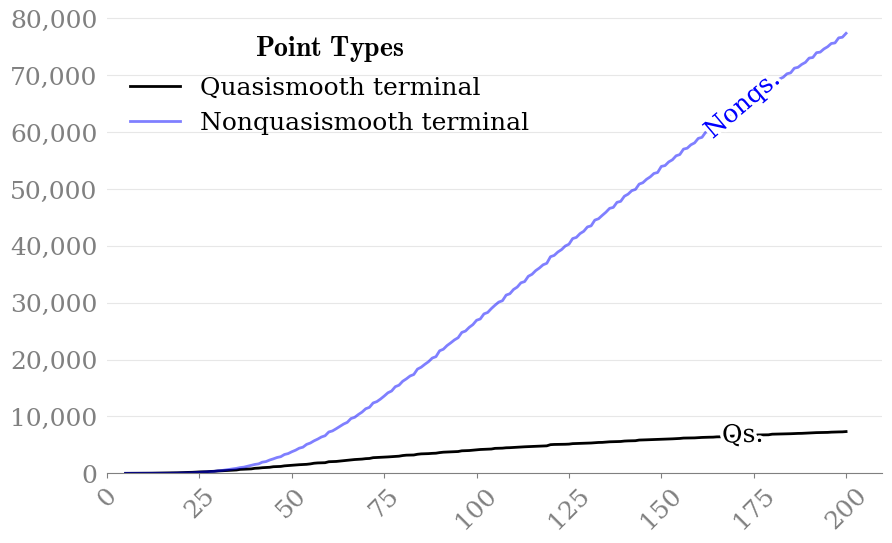

In [ ]:
#Calculate cumulative counts for each degree
qs_degrees = Counter(int(sum(point)) - 1 for point in exhaustive_terminal_points_qs)
nonqs_degrees = Counter(int(sum(point)) - 1 for point in exhaustive_terminal_points_nonqs)
all_degrees = sorted(set(qs_degrees) | set(nonqs_degrees))
degree_vs_qs = pd.DataFrame({
    "degree": all_degrees,
    "count": [qs_degrees.get(d, 0) for d in all_degrees]
})
degree_vs_qs["count"] = degree_vs_qs["count"].cumsum()
degree_vs_nonqs = pd.DataFrame({
    "degree": all_degrees,
    "count": [nonqs_degrees.get(d, 0) for d in all_degrees]
})
degree_vs_nonqs["count"] = degree_vs_nonqs["count"].cumsum()

#Font settings
plt.rcParams.update({
    "text.usetex": False,      
    "font.family": "serif",    
    "font.serif": ["DejaVu Serif"],  
    "mathtext.fontset": "cm",
})

#Instantiate plot
fig, ax = plt.subplots(figsize=(10, 6))
lines = []
xvals = []

#Quasismooth
line = ax.plot(degree_vs_qs["degree"], degree_vs_qs["count"], color='black', linewidth=2, label='Quasismooth terminal')
lines.append(line)
xvals.append(degree_vs_qs["degree"].iloc[-1]*0.86)

#Nonquasismooth
line = ax.plot(degree_vs_nonqs["degree"], degree_vs_nonqs["count"], color='blue', alpha=0.5, linewidth=2, label='Nonquasismooth terminal')
lines.append(line)
xvals.append(degree_vs_nonqs["degree"].iloc[-1]*0.86)


#Format plot
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))  # adds commas to x-axis
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))  # adds commas to y-axis
ax.grid(axis="y", alpha=0.3, linestyle='-')
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines['bottom'].set_color("grey")
ax.tick_params(axis='x', colors="grey")
ax.xaxis.label.set_color("grey")
ax.yaxis.label.set_color("grey")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.yaxis.set_tick_params(width=0)
plt.xticks(rotation=45)
plt.xticks(fontsize=18, color='grey')
plt.yticks(fontsize=18, color='grey')

#Labels and legend
plt.legend(frameon=False, fontsize=18, loc='upper left', title = r"$\mathbf{Point\ Types}$", title_fontsize=20)
lines = ax.get_lines()
labels_for_lines = [f"Qs."] + [f"Nonqs."]
for line, label in zip(lines, labels_for_lines):
    line.set_label(label)
labelLines(lines, xvals=xvals, align=True, fontsize=18)

plt.show()

#Create data directory if it doesn't exist
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/exhaustive_qs_vs_nonqs.png", dpi=300, bbox_inches="tight")


In [ ]:
#Search data
d_max = 200    
state_dim = 6
alpha_X = 1

#Searched points projected onto 2-dimensional planes 
projected_points = [set() for _ in range(state_dim - 1)]
k=0
for d in range(6, d_max + 1):
    k+=1
    print(k)
    target = d + alpha_X
    for combo in combinations_with_replacement(range(1, target), 5):
        a6 = target - sum(combo)
        if a6 >= combo[-1]:
            point = combo + (a6,)
            for i in range(state_dim - 1):
                projected_points[i].add((point[i], point[i+1]))
projected_points = [list(s) for s in projected_points]

#Font settings
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",     
    "font.serif": ["DejaVu Serif"],  
    "mathtext.fontset": "cm",  
})

#Instantiate plot
fig, axs = plt.subplots(2, 3 , figsize=(30,20))
axs = axs.flatten()

#Project the data via (a1,...,an) -> (ai+1, ai+2) for i=0,...,n-2
for i in range(state_dim - 1):
    ax = axs[i]
    i1 = i
    i2 = i + 1
    
    #Determine grid size
    max_value = int(max(
        max(point[0] for point in projected_points[i]),
        max(point[1] for point in projected_points[i]),
    ))

    #Grid points
    X, Y = np.meshgrid(range(1, max_value + 1), range(1, max_value + 1))
    X = X.flatten()
    Y = Y.flatten()

    #Marker size
    ax_width = ax.get_window_extent().width
    ax_height = ax.get_window_extent().height
    marker_size = (min(ax_width/ max_value, ax_height/ max_value) * 0.85) ** 2 

    #Grey points where ai<=aj
    grey_mask = X <= Y
    ax.scatter(X[grey_mask], Y[grey_mask], color='#eeeee4', s=marker_size, alpha=1, label='Searchable')

    #Searched points
    ax_ay_searched = list(set([(point[0],point[1]) for point in projected_points[i]]))
    ax.scatter(*zip(*ax_ay_searched), color='orange', s=marker_size, alpha=1, label='Searched')

    #Quasismooth terminal points
    ax_ay_terminal = list(set([(point[i1],point[i2]) for point in exhaustive_terminal_points_qs]))
    ax.scatter(*zip(*ax_ay_terminal), color='black', s=marker_size, alpha=1, label='Quasismooth terminal')
    
    #Nonquasismooth terminal points
    ax_ay_terminal = list(set([(point[i1],point[i2]) for point in exhaustive_terminal_points_nonqs]))
    ax.scatter(*zip(*ax_ay_terminal), color='blue', s=marker_size, alpha=0.5, label='Nonquasismooth terminal')
    
    #Lablels and title
    ax.set_xlabel(f'$a_{i1+1}$', fontsize=40, color='grey')
    ax.set_ylabel(f'$a_{i2+1}$', fontsize=40, color='grey')

    #Format plot
    num_bins = 6
    ticks = list(np.linspace(0, max_value, num_bins))  # 0, ..., max_value
    ticks.append(1)  # add 1
    ticks = sorted(set(ticks))  # remove duplicates if 1 was already included
    ticks = [int(t) for t in ticks if t != 0]  # remove 0 if you don't want it labeled, and make them integers
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(axis='both', which='both', length=0, labelsize=20, colors="grey")

axs[state_dim - 1].axis('off')

#Legend
h, l = ax.get_legend_handles_labels()
axs[state_dim - 1].legend(
    h, l,
    frameon=False,
    markerscale=15,
    loc='center',         
    fontsize=40,
    title=r'$\mathbf{Point\ Types}$',
    title_fontsize=45
)

plt.tight_layout()
plt.show()

#Create data directory if it doesn't exist
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/exhaustive_search.png", dpi=300, bbox_inches="tight")



1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
